# Giai đoạn 1 - CV Text Extractor

Notebook nay duoc sap xep theo 3 muc CV:
- Muc 1: PDF text-based
- Muc 2: PDF scan / image-based (hien moi detect, chua OCR)
- Muc 3: PDF multi-column / complex layout

Nhac nho quan trong:
- `extract_text_from_pdf()` la entry point chinh.
- Nhanh muc 3 da duoc thay bang extractor layout-aware moi.


## 1. Imports

In [1]:
import fitz
import re
import unicodedata
from collections import Counter
from pathlib import Path
from typing import Any, Optional

## 2. Utility va section config

Phan nay dung chung cho layout-aware extractor.

In [2]:
SECTION_ALIASES = {
    "personal_info": [
        "thong tin ca nhan", "lien he", "contact", "personal information"
    ],
    "skills": [
        "ky nang", "skills", "skill"
    ],
    "certificates": [
        "chung chi", "certificates", "certifications"
    ],
    "objective": [
        "muc tieu nghe nghiep", "objective", "career objective", "summary", "profile"
    ],
    "education": [
        "hoc van", "education", "academic background"
    ],
    "experience": [
        "kinh nghiem lam viec", "kinh nghiem", "work experience", "experience", "employment history"
    ],
    "activities": [
        "hoat dong", "activities"
    ],
    "projects": [
        "du an", "projects"
    ],
    "languages": [
        "ngon ngu", "languages"
    ],
}


SECTION_TITLES = {
    "header": "THONG TIN DAU CV",
    "personal_info": "THONG TIN CA NHAN",
    "objective": "MUC TIEU NGHE NGHIEP",
    "education": "HOC VAN",
    "experience": "KINH NGHIEM LAM VIEC",
    "skills": "KY NANG",
    "certificates": "CHUNG CHI",
    "activities": "HOAT DONG",
    "projects": "DU AN",
    "languages": "NGON NGU",
    "other": "KHAC",
}


PREFERRED_SECTION_ORDER = [
    "header",
    "personal_info",
    "objective",
    "education",
    "experience",
    "skills",
    "certificates",
    "activities",
    "projects",
    "languages",
    "other",
]


def normalize_pdf_text(text: str) -> str:
    if not text:
        return ""

    text = text.replace("\x00", " ")
    text = text.replace("\u00a0", " ")
    text = re.sub(r"\r\n|\r", "\n", text)

    lines = [re.sub(r"[ \t]+", " ", line).strip() for line in text.split("\n")]

    cleaned_lines = []
    prev_empty = False
    for line in lines:
        if not line:
            if not prev_empty:
                cleaned_lines.append("")
            prev_empty = True
        else:
            cleaned_lines.append(line)
            prev_empty = False

    return "\n".join(cleaned_lines).strip()


def remove_vietnamese_accents(text: str) -> str:
    if not text:
        return ""

    text = text.replace("\u0111", "d").replace("\u0110", "D")
    text = unicodedata.normalize("NFD", text)
    text = "".join(ch for ch in text if unicodedata.category(ch) != "Mn")
    return unicodedata.normalize("NFC", text)


def normalize_for_heading(text: str) -> str:
    if not text:
        return ""

    text = unicodedata.normalize("NFC", text)
    text = remove_vietnamese_accents(text).lower()
    text = re.sub(r"[\ue000-\uf8ff]", " ", text)
    text = re.sub(r"[^a-z0-9\s&/+-]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


NORMALIZED_SECTION_ALIASES = {
    section: {normalize_for_heading(alias) for alias in aliases}
    for section, aliases in SECTION_ALIASES.items()
}


def detect_section_heading(text: str) -> Optional[str]:
    norm = normalize_for_heading(text)

    if not norm:
        return None

    for section, aliases in NORMALIZED_SECTION_ALIASES.items():
        if norm in aliases:
            return section

    return None


def clean_line_text(text: str) -> str:
    if not text:
        return ""

    text = unicodedata.normalize("NFC", text)
    text = text.replace("\x00", " ")
    text = text.replace("\u00a0", " ")
    text = re.sub(r"[\ue000-\uf8ff]", " ", text)
    text = re.sub(r"[\U0001F4C5\U0001F464\U00002709\U0000260E\U0001F4DE\U0001F4CD\U0001F517\U0001F310\U0001F3E0\U0001F382]", " ", text)
    text = re.sub(r"[\u2022\u25cf\u25aa\u25a0\u25c6\u25b6\u25ba]", "-", text)
    text = text.replace("\u2013", "-").replace("\u2014", "-")
    text = re.sub(r"[ \t]+", " ", text)
    return text.strip()


def clean_cv_text(text: str) -> str:
    if not text:
        return ""

    text = unicodedata.normalize("NFC", text)
    text = text.replace("\x00", " ")
    text = text.replace("\u00a0", " ")
    text = re.sub(r"\r\n|\r", "\n", text)
    text = re.sub(r"[ \t]+", " ", text)

    lines = [line.strip() for line in text.split("\n")]

    cleaned_lines = []
    prev_empty = False
    for line in lines:
        if not line:
            if not prev_empty:
                cleaned_lines.append("")
            prev_empty = True
        else:
            cleaned_lines.append(line)
            prev_empty = False

    text = "\n".join(cleaned_lines)
    text = re.sub(r"\n{3,}", "\n\n", text)
    return text.strip()


## 3. PDF type detection

Phan nay dung de phan loai PDF truoc khi chon extractor.

In [3]:
def is_probably_scanned_pdf(pdf_path: str, min_chars_per_page: int = 80) -> bool:
    doc = fitz.open(str(pdf_path))

    try:
        if len(doc) == 0:
            return True

        total_chars = 0
        for page in doc:
            text = page.get_text("text") or ""
            total_chars += len(text.strip())

        avg_chars = total_chars / len(doc)
        return avg_chars < min_chars_per_page
    finally:
        doc.close()


def is_probably_multi_column(pdf_path: str, min_x_spread: int = 180, min_blocks: int = 8) -> bool:
    doc = fitz.open(str(pdf_path))

    try:
        for page in doc:
            blocks = page.get_text("blocks")
            text_blocks = []

            for block in blocks:
                x0, y0, x1, y1, text, block_no, block_type = block

                if block_type != 0:
                    continue

                if text and len(text.strip()) > 20:
                    text_blocks.append((x0, y0, x1, y1, text))

            if len(text_blocks) >= min_blocks:
                x_positions = [b[0] for b in text_blocks]
                x_spread = max(x_positions) - min(x_positions)

                if x_spread >= min_x_spread:
                    return True

        return False
    finally:
        doc.close()


## 4. Extractor theo tung muc CV

### Muc 1 - Text-based PDF

Duong don gian de lam baseline va fallback.

In [4]:
def extract_text_by_simple(pdf_path: Path) -> str:
    doc = fitz.open(pdf_path)
    pages_text = []

    for page in doc:
        text = page.get_text("text")
        if text:
            pages_text.append(text)

    doc.close()
    return normalize_pdf_text("\n".join(pages_text))


### Muc 2 - Multi-column / complex layout PDF

Nhanh muc 3 da duoc thay bang layout-aware extractor moi. Nhanh nay lam viec tren word + toa do, tach cot, tach section, roi build lai plain text.

In [5]:
# Lấy toàn bộ các từ trên một trang PDF cùng với tọa độ bounding box của chúng (x0, y0, x1, y1)
def get_valid_words(page) -> list[dict[str, Any]]:
    raw_words = page.get_text("words")
    valid_words = []

    for w in raw_words:
        x0, y0, x1, y1, word, *_ = w
        word = clean_line_text(str(word))

        if not word:
            continue

        valid_words.append({
            "x0": float(x0),
            "y0": float(y0),
            "x1": float(x1),
            "y1": float(y1),
            "text": word,
            "y_center": (float(y0) + float(y1)) / 2,
        })

    return valid_words

# Nhóm các từ thành các dòng dựa trên tọa độ y_center của chúng, với một ngưỡng y_tolerance để xác định xem chúng có thuộc cùng một dòng hay không
def group_words_into_rows(words: list[dict[str, Any]], y_tolerance: float = 5.0) -> list[list[dict[str, Any]]]:
    words = sorted(words, key=lambda w: (w["y_center"], w["x0"]))

    rows = []
    current_row = []
    current_y = None

    for word in words:
        if current_y is None:
            current_row = [word]
            current_y = word["y_center"]
            continue

        if abs(word["y_center"] - current_y) <= y_tolerance:
            current_row.append(word)
            current_y = sum(w["y_center"] for w in current_row) / len(current_row)
        else:
            rows.append(current_row)
            current_row = [word]
            current_y = word["y_center"]

    if current_row:
        rows.append(current_row)

    for row in rows:
        row.sort(key=lambda w: w["x0"])

    return rows

# Gộp một danh sách các từ thành một dòng duy nhất, tính toán bounding box tổng thể và nối các từ lại với nhau để tạo thành văn bản của dòng đó
def make_line_from_words(words: list[dict[str, Any]]) -> Optional[dict[str, Any]]:
    if not words:
        return None

    words = sorted(words, key=lambda w: w["x0"])
    text = " ".join(w["text"] for w in words)
    text = clean_line_text(text)

    if not text:
        return None

    return {
        "x0": min(w["x0"] for w in words),
        "y0": min(w["y0"] for w in words),
        "x1": max(w["x1"] for w in words),
        "y1": max(w["y1"] for w in words),
        "text": text,
    }


# Gộp các từ trong mỗi dòng thành một dòng duy nhất, nhưng chỉ tách chúng thành các dòng riêng biệt nếu khoảng cách x giữa chúng vượt quá một ngưỡng nhất định (x_gap_threshold)    
def rows_to_lines_by_x_gap(rows: list[list[dict[str, Any]]], x_gap_threshold: float = 50.0) -> list[dict[str, Any]]:
    lines = []

    for row in rows:
        current_segment = []
        prev_x1 = None

        for word in row:
            if prev_x1 is not None and word["x0"] - prev_x1 > x_gap_threshold:
                line = make_line_from_words(current_segment)
                if line:
                    lines.append(line)
                current_segment = [word]
            else:
                current_segment.append(word)

            prev_x1 = word["x1"]

        if current_segment:
            line = make_line_from_words(current_segment)
            if line:
                lines.append(line)

    return lines

#Phân tích tọa độ X để đoán xem trang này có 2 cột không. Nếu có, trả về vị trí X của cột trái và cột phải, cũng như điểm giữa để tách cột. Nếu không chắc chắn, trả về None.
def detect_two_column_layout(rough_lines: list[dict[str, Any]], page_width: float) -> Optional[dict[str, float]]:
    x_bins = []

    for line in rough_lines:
        text = line["text"]

        if len(text) < 2:
            continue

        x_bin = round(line["x0"] / 5) * 5
        x_bins.append(x_bin)

    if len(x_bins) < 2:
        return None

    counter = Counter(x_bins)
    min_count = max(2, int(len(rough_lines) * 0.04))

    candidates = sorted(x for x, count in counter.items() if count >= min_count)
    if len(candidates) < 2:
        return None

    gaps = []
    for left_x, right_x in zip(candidates, candidates[1:]):
        gap = right_x - left_x

        if left_x > page_width * 0.35 and right_x > page_width * 0.78:
            continue

        gaps.append((gap, left_x, right_x))

    if not gaps:
        return None

    max_gap, left_start, right_start = max(gaps, key=lambda item: item[0])
    min_gap = max(55, page_width * 0.08)

    if max_gap < min_gap:
        return None

    return {
        "left_start": float(left_start),
        "right_start": float(right_start),
        "split_x": float((left_start + right_start) / 2),
    }

# Dựa trên vị trí bắt đầu của cột phải (right_start_x) và một khoảng cách lề (column_margin), phân loại các từ trong mỗi dòng thành cột trái hoặc cột phải, sau đó gộp chúng thành các dòng hoàn chỉnh cho từng cột. Trả về hai danh sách các dòng cho cột trái và cột phải, được sắp xếp theo thứ tự xuất hiện trên trang.
def rows_to_column_lines(rows: list[list[dict[str, Any]]], right_start_x: float, column_margin: float = 8.0) -> tuple[list[dict[str, Any]], list[dict[str, Any]]]:
    left_lines = []
    right_lines = []
    threshold = right_start_x - column_margin

    for row in rows:
        left_words = []
        right_words = []

        for word in row:
            if word["x0"] >= threshold:
                right_words.append(word)
            else:
                left_words.append(word)

        left_line = make_line_from_words(left_words)
        right_line = make_line_from_words(right_words)

        if left_line:
            left_lines.append(left_line)
        if right_line:
            right_lines.append(right_line)

    left_lines.sort(key=lambda line: (line["y0"], line["x0"]))
    right_lines.sort(key=lambda line: (line["y0"], line["x0"]))
    return left_lines, right_lines

# Gộp các từ trong mỗi dòng thành một dòng duy nhất, không tách chúng thành các dòng riêng biệt dựa trên khoảng cách x, sau đó sắp xếp tất cả các dòng theo thứ tự xuất hiện trên trang (đầu tiên theo y0, sau đó theo x0).
def rows_to_single_column_lines(rows: list[list[dict[str, Any]]]) -> list[dict[str, Any]]:
    lines = []

    for row in rows:
        line = make_line_from_words(row)
        if line:
            lines.append(line)

    lines.sort(key=lambda line: (line["y0"], line["x0"]))
    return lines

# Phân tích các dòng đã gộp để phát hiện các tiêu đề phần dựa trên văn bản của chúng, sau đó phân loại các dòng thành phần dẫn đầu (trước tiêu đề phần đầu tiên) và các phần tương ứng dựa trên tiêu đề đã phát hiện. Trả về một danh sách các dòng dẫn đầu và một dictionary ánh xạ tên phần sang danh sách các dòng thuộc phần đó.
def parse_sections_from_lines(lines: list[dict[str, Any]]) -> tuple[list[str], dict[str, list[str]]]:
    leading_lines = []
    sections = {}
    current_section = None

    for line in lines:
        text = line["text"].strip()

        if not text:
            continue

        detected_section = detect_section_heading(text)
        if detected_section:
            current_section = detected_section
            sections.setdefault(current_section, [])
            continue

        if current_section is None:
            leading_lines.append(text)
        else:
            sections.setdefault(current_section, []).append(text)

    return leading_lines, sections

# Hợp nhất các phần từ một nguồn vào phần tương ứng trong đích, thêm các dòng vào danh sách hiện có cho phần đó. Nếu phần chưa tồn tại trong đích, tạo nó trước khi thêm các dòng.
def merge_sections(target: dict[str, list[str]], source: dict[str, list[str]]) -> None:
    for section, lines in source.items():
        target.setdefault(section, [])
        target[section].extend(lines)

# Loại bỏ các dòng trùng lặp trong một danh sách, nhưng giữ nguyên thứ tự xuất hiện của chúng. Trả về một danh sách mới chỉ chứa các dòng duy nhất theo thứ tự ban đầu.
def remove_duplicate_keep_order(lines: list[str]) -> list[str]:
    result = []
    seen = set()

    for line in lines:
        key = normalize_for_heading(line)

        if not key:
            continue
        if key in seen:
            continue

        seen.add(key)
        result.append(line)

    return result

# Xây dựng văn bản thuần túy cuối cùng từ các phần đã trích xuất, sắp xếp chúng theo thứ tự ưu tiên đã định trước, loại bỏ các dòng trùng lặp trong mỗi phần và thêm tiêu đề phần tương ứng trước mỗi phần. Kết quả là một chuỗi văn bản đã được làm sạch và tổ chức tốt.
def build_plain_text(sections: dict[str, list[str]]) -> str:
    parts = []

    for section in PREFERRED_SECTION_ORDER:
        lines = sections.get(section, [])
        lines = remove_duplicate_keep_order(lines)

        if not lines:
            continue

        title = SECTION_TITLES.get(section, section.upper())
        parts.append(title)
        parts.extend(lines)
        parts.append("")

    return clean_cv_text("\n".join(parts))

# Hàm chính để trích xuất văn bản từ CV PDF, có khả năng nhận biết bố cục nhiều cột và các phần khác nhau. Nó sử dụng PyMuPDF để đọc PDF, phân tích bố cục dựa trên tọa độ của các từ, và tổ chức văn bản thành các phần có ý nghĩa như thông tin cá nhân, kỹ năng, kinh nghiệm, v.v. Kết quả là một dictionary chứa văn bản thuần túy đã được tổ chức theo phần, cùng với thông tin về loại PDF và bất kỳ cảnh báo nào nếu có.
def extract_cv_layout_aware(pdf_path: str | Path, y_tolerance: float = 4.0, x_gap_threshold: float = 50.0, column_margin: float = 8.0) -> dict[str, Any]:
    pdf_path = str(pdf_path)

    if not Path(pdf_path).exists():
        raise FileNotFoundError(f"File not found: {pdf_path}")

    result = {
        "text": "",
        "sections": {section: [] for section in PREFERRED_SECTION_ORDER},
        "pdf_type": "multi_column_or_complex_layout",
        "method": "pymupdf_words_layout_level3",
        "warnings": [],
        "layout_debug": [],
    }

    if is_probably_scanned_pdf(pdf_path):
        result["pdf_type"] = "scan_or_image_based"
        result["method"] = "none"
        result["warnings"].append("PDF co ve la file scan/anh hoac co qua it text. Can OCR de doc noi dung.")
        return result

    doc = fitz.open(pdf_path)

    try:
        for page_index, page in enumerate(doc):
            words = get_valid_words(page)

            if not words:
                result["warnings"].append(f"Trang {page_index + 1} khong lay duoc word nao.")
                continue

            rows = group_words_into_rows(words, y_tolerance=y_tolerance)
            rough_lines = rows_to_lines_by_x_gap(rows, x_gap_threshold=x_gap_threshold)
            layout = detect_two_column_layout(rough_lines, page_width=page.rect.width)

            if layout:
                left_lines, right_lines = rows_to_column_lines(rows, right_start_x=layout["right_start"], column_margin=column_margin)

                left_leading, left_sections = parse_sections_from_lines(left_lines)
                right_leading, right_sections = parse_sections_from_lines(right_lines)

                if page_index == 0:
                    result["sections"]["header"].extend(left_leading)
                    result["sections"]["header"].extend(right_leading)
                else:
                    result["sections"]["other"].extend(left_leading)
                    result["sections"]["other"].extend(right_leading)

                merge_sections(result["sections"], left_sections)
                merge_sections(result["sections"], right_sections)

                result["layout_debug"].append({
                    "page": page_index + 1,
                    "layout": "two_columns",
                    "left_start": layout["left_start"],
                    "right_start": layout["right_start"],
                    "split_x": layout["split_x"],
                    "left_line_count": len(left_lines),
                    "right_line_count": len(right_lines),
                })
            else:
                lines = rows_to_single_column_lines(rows)
                leading, sections = parse_sections_from_lines(lines)

                if page_index == 0:
                    result["sections"]["header"].extend(leading)
                else:
                    result["sections"]["other"].extend(leading)

                merge_sections(result["sections"], sections)

                result["layout_debug"].append({
                    "page": page_index + 1,
                    "layout": "single_column",
                    "line_count": len(lines),
                })
    finally:
        doc.close()

    for section, lines in result["sections"].items():
        result["sections"][section] = remove_duplicate_keep_order(lines)

    result["text"] = build_plain_text(result["sections"])

    if len(result["text"]) < 300:
        result["warnings"].append("Text sau trich xuat kha ngan. Co the PDF bi scan, bi khoa hoac layout qua phuc tap.")

    return result


In [6]:
def append_layout_result_from_words(
    result: dict[str, Any],
    words: list[dict[str, Any]],
    page_width: float,
    page_index: int,
    y_tolerance: float = 4.0,
    x_gap_threshold: float = 50.0,
    column_margin: float = 8.0,
) -> None:
    if not words:
        result["warnings"].append(f"Trang {page_index + 1} không lấy được word nào.")
        return

    rows = group_words_into_rows(words, y_tolerance=y_tolerance)
    rough_lines = rows_to_lines_by_x_gap(rows, x_gap_threshold=x_gap_threshold)
    layout = detect_two_column_layout(rough_lines, page_width=page_width)

    if layout:
        left_lines, right_lines = rows_to_column_lines(
            rows,
            right_start_x=layout["right_start"],
            column_margin=column_margin,
        )

        left_leading, left_sections = parse_sections_from_lines(left_lines)
        right_leading, right_sections = parse_sections_from_lines(right_lines)

        if page_index == 0:
            result["sections"]["header"].extend(left_leading + right_leading)
        else:
            result["sections"]["other"].extend(left_leading + right_leading)

        merge_sections(result["sections"], left_sections)
        merge_sections(result["sections"], right_sections)

        result["layout_debug"].append(
            {
                "page": page_index + 1,
                "layout": "two_columns_from_ocr_words",
                "left_start": layout["left_start"],
                "right_start": layout["right_start"],
                "split_x": layout["split_x"],
                "left_line_count": len(left_lines),
                "right_line_count": len(right_lines),
                "word_count": len(words),
            }
        )
        return

    lines = rows_to_single_column_lines(rows)
    leading_lines, sections = parse_sections_from_lines(lines)

    if page_index == 0:
        result["sections"]["header"].extend(leading_lines)
    else:
        result["sections"]["other"].extend(leading_lines)

    merge_sections(result["sections"], sections)

    result["layout_debug"].append(
        {
            "page": page_index + 1,
            "layout": "single_column_from_ocr_words",
            "line_count": len(lines),
            "word_count": len(words),
        }
    )
    
    

### Muc 3 - Scan / image-based PDF

Hien tai chi detect scan PDF. OCR se lam sau.

In [20]:
import io

from PIL import Image, ImageFilter, ImageOps
import matplotlib.pyplot as plt
import pytesseract
from pytesseract import Output

In [ ]:
OCR_LANG = "vie+eng"
OCR_RENDER_DPI = 300
OCR_LAYOUT_PSM = 3
OCR_MIN_CONFIDENCE = 30
OCR_MIN_TEXT_LENGTH = 40

pytesseract.pytesseract.tesseract_cmd = r'C:\Program Files\Tesseract-OCR\tesseract.exe'

In [9]:
def build_empty_sections()-> dict[str, list[str]]:
    return {section: [] for section in PREFERRED_SECTION_ORDER}

def build_extraction_result(pdf_type: str,
    method: str,
    text: str = "",
    warnings: list[str] | None = None,
) -> dict[str, Any]:
    return {
        "text": text,
        "sections": build_empty_sections(),
        "pdf_type": pdf_type,
        "method": method,
        "warnings": list(warnings or []),
        "layout_debug": [],
    }

Hàm chuyển 1 trang pdf sang ảnh nhận đầu vào là 1 trang pdf và độ phân giải:
- 1 trang pdf mặc định có độ phân giải 72 DPI, nên để đạt được độ phân giải mong muốn, ta cần zoom lên theo tỷ lệ dpi/72
- Tạo ma trận hình học để phóng to pdf theo X và Y đúng tỉ lệ vừa tính (gấp dpi/72)
- Gói dữ liệu pixel thpp thành 1 chuỗi byte theo chuẩn cấu trúc của png
- Chuyển đổi sang RGB để đảm bảo tesseract xử lý tốt hơn

In [10]:
def render_pdf_page_to_image(page: fitz.Page,
    dpi: int = OCR_RENDER_DPI, #dpi: độ phân giải
) -> Image.Image:
    zoom = dpi/72 
    matrix = fitz.Matrix(zoom, zoom) 
    pixmap = page.get_pixmap(matrix=matrix, alpha=False)
    image_bytes = pixmap.tobytes("png")
    return Image.open(io.BytesIO(image_bytes)).convert("RGB") 

Hàm tiền xử lý ảnh trước OCR (nhận tham số là 1 ảnh và trả về 1 ảnh đã xử lý):
- Chuyển ảnh sang thang độ xám (vì đôi khi chữ sẽ có những màu khác nhau, đưa hết về màu xám để loại bỏ thông tin màu không cần thiết)
- Tự động điều chỉnh độ tương phản để làm rõ chữ
- Áp dụng bộ lọc trung vị để giảm nhiễu (trượt qua toàn bộ ảnh, thay thế giá trị của điểm ảnh ở giữa bằng giá trị trung bình của các điểm xung quanh => Xóa các hạt nhiễu li ti trên ảnh)
- Chuyển ảnh thành đen trắng với ngưỡng 180
    + Nếu độ sáng của pixel > 180 => ép nó thành màu trắng (255)
    + Nếu độ sáng < = 180 => Ép nó thành màu đen (0)
- Chuyển ảnh nhị phân sang thang độ xám để OCR hoạt động tốt hơn

In [33]:
def show_image_for_debug(
    image: Image.Image,
    title: str = "OCR Debug Image",
    figsize: tuple[int, int] = (10, 12),
) -> None:
    plt.figure(figsize=figsize)
    plt.imshow(image, cmap="gray")
    plt.title(title)
    plt.axis("off")
    plt.show()

def preprocess_image_for_ocr(image: Image.Image, show_steps: bool = False) -> Image.Image:
    gray = ImageOps.grayscale(image) 
    gray = ImageOps.autocontrast(gray) 
    denoised = gray.filter(ImageFilter.MedianFilter(size=3)) 
    
    binary = denoised.point(lambda x: 255 if x > 180 else 0, mode="1")
    processed = binary.convert("L")

    if show_steps:
        show_image_for_debug(image, title="0. Original Rendered Image")
        show_image_for_debug(gray, title="1. Gray + Autocontrast")
        show_image_for_debug(denoised, title="2. Denoised")
        show_image_for_debug(processed, title="3. Final Preprocessed Image")

    return processed


Tách từ một kèm theo tọa độ chính xác của nó thông qua ảnh trong pdf:
- Đưa ảnh qua tiền xử lý
- Trích xuất dữ liệu chi tiết, dùng image_to_data
    + Sử dụng tham số output_type = Output.DICT => Yêu cầu Tesseract trả kết quả về dạng một Dictionary cuả Python
- Tạo valid_words chứa kết quả
- Vòng lặp chạy qua từng từ mà ocr nhận diện được
    + Nó lấy ra chữ tại vị trí index, loại bỏ khoảng trắng thừa và đưa qua hàm clean_line_texxt để xóa bỏ kí tự rác
- conf: thể hiện mức độ tự tin của engine khi đọc từ đó
- Nếu như điểm tự tin nhỏ hơn ngưỡng cho phép thì không lưu từ đó
- Trích xuất tọa độ hộp bao quanh từ đó
=> Đóng gói kết quả và lưu vào valid_words

In [ ]:
def extract_words_from_ocr_image(image: Image.Image, lang: str = OCR_LANG, psm: int = OCR_LAYOUT_PSM, min_confidence: int = OCR_MIN_CONFIDENCE, show_preprocessed: bool = False) -> list[dict[str, Any]]:

    processed_image = preprocess_image_for_ocr(
        image = image,
        show_steps=show_preprocessed
    )

    ocr_data = pytesseract.image_to_data(
        processed_image,
        lang=lang,
        config=f"--oem 3 --psm {psm}",
        output_type=Output.DICT
    )

    valid_words: list[dict[str, Any]] = []
    total_items = len(ocr_data["text"])

    for index in range(total_items):
        text = str(ocr_data["text"][index] or "").strip()
        text = clean_line_text(text)

        conf_raw = str(ocr_data["conf"][index]).strip()

        try:
            confidence = float(conf_raw)
        except ValueError:
            confidence = -1.0

        if not text:
            continue
        if confidence < min_confidence:
            continue

        left = float(ocr_data["left"][index])
        top = float(ocr_data["top"][index])
        width = float(ocr_data["width"][index])
        height = float(ocr_data["height"][index])

        x0 = left
        y0 = top
        x1 = left + width
        y1 = top + height
        
        valid_words.append(
            {
                "x0": x0,
                "y0": y0,
                "x1": x1,
                "y1": y1,
                "text": text,
                "y_center": (y0 + y1) / 2,
                "confidence": confidence,
            }
        )

    return valid_words

Đoán layout từ words:
- Gom dòng: Nhóm các từ nằm trên cùng một độ cao (tọa độ Y) thành các hàng ngang.
- Dò tìm Cột (Detection): Tìm các khoảng trắng lớn vắt ngang qua các hàng để xác định xem CV này có chia 2 cột hay chỉ là 1 cột từ trên xuống.
- Tách và Phân loại (Parsing): * Cắt đôi văn bản (nếu là 2 cột).
    + Đọc dọc theo từng cột để tìm các Tiêu đề (Heading) và chia text thành từng mục (như "Kinh nghiệm", "Học vấn").
- Tổng hợp (Merging): Lắp ghép các mục vừa phân loại được vào đúng vị trí trong file JSON kết quả cuối cùng.

In [35]:
def append_layout_result_from_words(
    result: dict[str, Any],
    words: list[dict[str, Any]],
    page_width: float,
    page_index: int,
    y_tolerance: float = 4.0,
    x_gap_threshold: float = 50.0,
    column_margin: float = 8.0,
) -> None:
    if not words:
        result["warnings"].append(f"Trang {page_index + 1} không lấy được word nào.")
        return

    rows = group_words_into_rows(words, y_tolerance=y_tolerance)
    rough_lines = rows_to_lines_by_x_gap(rows, x_gap_threshold=x_gap_threshold)
    layout = detect_two_column_layout(rough_lines, page_width=page_width)

    if layout:
        left_lines, right_lines = rows_to_column_lines(
            rows,
            right_start_x=layout["right_start"],
            column_margin=column_margin,
        )

        left_leading, left_sections = parse_sections_from_lines(left_lines)
        right_leading, right_sections = parse_sections_from_lines(right_lines)

        if page_index == 0:
            result["sections"]["header"].extend(left_leading + right_leading)
        else:
            result["sections"]["other"].extend(left_leading + right_leading)

        merge_sections(result["sections"], left_sections)
        merge_sections(result["sections"], right_sections)

        result["layout_debug"].append(
            {
                "page": page_index + 1,
                "layout": "two_columns_from_ocr_words",
                "left_start": layout["left_start"],
                "right_start": layout["right_start"],
                "split_x": layout["split_x"],
                "left_line_count": len(left_lines),
                "right_line_count": len(right_lines),
                "word_count": len(words),
            }
        )
        return

    lines = rows_to_single_column_lines(rows)
    leading_lines, sections = parse_sections_from_lines(lines)

    if page_index == 0:
        result["sections"]["header"].extend(leading_lines)
    else:
        result["sections"]["other"].extend(leading_lines)

    merge_sections(result["sections"], sections)

    result["layout_debug"].append(
        {
            "page": page_index + 1,
            "layout": "single_column_from_ocr_words",
            "line_count": len(lines),
            "word_count": len(words),
        }
    )
    


In [ ]:
def compute_line_stats(lines: list[dict[str, Any]]) -> dict[str, float]:
    """Tính thống kê cơ bản để quyết định merge dòng."""
    if not lines:
        return {
            "median_height": 0.0,
            "median_gap": 0.0,
        }

    heights = [max(1.0, line["y1"] - line["y0"]) for line in lines]

    gaps = []
    for prev_line, next_line in zip(lines, lines[1:]):
        gap = next_line["y0"] - prev_line["y1"]
        if gap >= 0:
            gaps.append(gap)

    def median(values: list[float]) -> float:
        if not values:
            return 0.0
        values = sorted(values)
        mid = len(values) // 2
        if len(values) % 2 == 1:
            return float(values[mid])
        return float(values[mid - 1] + values[mid]) / 2

    return {
        "median_height": median(heights),
        "median_gap": median(gaps),
    }

def is_wrapped_continuation(
    current_line: dict[str, Any],
    next_line: dict[str, Any],
    stats: dict[str, float],
) -> bool:
    """Đoán xem next_line có phải phần tiếp theo của current_line không."""
    current_text = current_line["text"].strip()
    next_text = next_line["text"].strip()

    if not current_text or not next_text:
        return False

    # Neu dong sau la heading moi thi khong merge
    if detect_section_heading(next_text):
        return False

    # Neu dong sau trong giong title / moc thoi gian moi thi khong merge
    if YEAR_RANGE_RE.search(normalize_for_heading(next_text)):
        return False
    if looks_like_title_line(next_text):
        return False

    # Neu dong sau bat dau bang bullet manh thi thuong la y moi
    if re.match(r"^[-*•]", next_text):
        return False

    median_height = max(1.0, stats.get("median_height", 0.0))
    median_gap = stats.get("median_gap", 0.0)

    vertical_gap = max(0.0, next_line["y0"] - current_line["y1"])
    x_shift = abs(next_line["x0"] - current_line["x0"])

    # Nguong gap nho -> nghieng ve kha nang la xuong dong tu dong
    small_gap_threshold = max(6.0, median_gap * 1.5, median_height * 0.35)

    # Lech cot qua nhieu thi khong merge
    max_same_column_shift = max(18.0, median_height * 1.2)

    if vertical_gap > small_gap_threshold:
        return False

    if x_shift > max_same_column_shift:
        return False

    current_norm = normalize_for_heading(current_text)
    next_norm = normalize_for_heading(next_text)

    # Neu dong truoc ket thuc ro rang thi thuong la y da xong
    if re.search(r"[.!?:;]$", current_text):
        return False

    # Neu dong sau mo dau bang chu thuong / so / ky tu tiep noi
    if re.match(r"^[a-z0-9(,/+-]", next_norm):
        return True

    # Neu dong truoc kha dai thi kha nang dong sau la phan tiep theo
    if len(current_text) >= 40:
        return True

    return False

def merge_wrapped_lines(lines: list[dict[str, Any]]) -> list[dict[str, Any]]:
    """Gộp các dòng bị xuống hàng tự động thành một dòng logic."""
    if not lines:
        return []

    sorted_lines = sorted(lines, key=lambda line: (line["y0"], line["x0"]))
    stats = compute_line_stats(sorted_lines)

    merged_lines: list[dict[str, Any]] = []
    current = dict(sorted_lines[0])

    for next_line in sorted_lines[1:]:
        if is_wrapped_continuation(current, next_line, stats):
            current["text"] = clean_line_text(current["text"] + " " + next_line["text"])
            current["x0"] = min(current["x0"], next_line["x0"])
            current["y0"] = min(current["y0"], next_line["y0"])
            current["x1"] = max(current["x1"], next_line["x1"])
            current["y1"] = max(current["y1"], next_line["y1"])
        else:
            merged_lines.append(current)
            current = dict(next_line)

    merged_lines.append(current)
    return merged_lines


In [27]:
# Loại bỏ các dòng trùng lặp trong một phần, giữ lại thứ tự xuất hiện ban đầu
def dedupe_lines_keep_order(lines: list[str]) -> list[str]: 
    result = []
    seen = set()

    for line in lines:
        key = normalize_for_heading(line)

        if not key:
            continue

        if key in seen:
            continue

        seen.add(key)
        result.append(line)

    return result

def extract_text_from_scanned_pdf_layout_aware(
    pdf_path: str | Path,
    dpi: int = OCR_RENDER_DPI,
    lang: str = OCR_LANG,
    psm: int = OCR_LAYOUT_PSM,
    min_confidence: int = OCR_MIN_CONFIDENCE,
    show_preprocessed_first_page: bool = False,
    y_tolerance: float = 4.0,
    x_gap_threshold: float = 50.0,
    column_margin: float = 8.0,
) -> dict[str, Any]:
    """OCR PDF scan theo hướng word-level rồi đưa vào layout parser."""
    pdf_path = Path(pdf_path)

    if not pdf_path.exists():
        raise FileNotFoundError(f"Không tìm thấy file: {pdf_path}")

    result = build_extraction_result(
        pdf_type="scan_or_image_based",
        method=f"ocr_words_layout_psm_{psm}",
        warnings=["Đã dùng OCR word-level vì PDF có vẻ là file scan/ảnh."],
    )

    document = fitz.open(str(pdf_path))

    try:
        for page_index, page in enumerate(document):
            image = render_pdf_page_to_image(page, dpi=dpi)
            words = extract_words_from_ocr_image(
                image=image,
                lang=lang,
                psm=psm,
                min_confidence=min_confidence,
                show_preprocessed=show_preprocessed_first_page and page_index == 0,
            )

            append_layout_result_from_words(
                result=result,
                words=words,
                page_width=image.width,
                page_index=page_index,
                y_tolerance=y_tolerance,
                x_gap_threshold=x_gap_threshold,
                column_margin=column_margin,
            )
    finally:
        document.close()

    for section, lines in result["sections"].items():
        result["sections"][section] = dedupe_lines_keep_order(lines)

    result["text"] = build_plain_text(result["sections"])

    if len(result["text"]) < OCR_MIN_TEXT_LENGTH:
        result["warnings"].append(
            "Text OCR khá ngắn. Có thể ảnh mờ, lệch, hoặc layout scan quá khó."
        )

    return result


## 5. Orchestrator

Ham nay la entry point chinh. Neu la scan PDF thi dung. Neu la multi-column thi goi extractor layout-aware moi. Neu la text-based don gian thi di duong baseline.

In [31]:
def extract_text_from_pdf(pdf_path: Path | str) -> dict[str, Any]:
    pdf_path = str(pdf_path)

    if not Path(pdf_path).exists():
        raise FileNotFoundError(f"File not found: {pdf_path}")

    if is_probably_scanned_pdf(pdf_path):
        return extract_text_from_scanned_pdf_layout_aware(pdf_path, show_preprocessed_first_page=True)

    if is_probably_multi_column(pdf_path):
        return extract_cv_layout_aware(pdf_path)

    text = extract_text_by_simple(pdf_path)
    result = {
        "text": text,
        "sections": {section: [] for section in PREFERRED_SECTION_ORDER},
        "pdf_type": "text_based",
        "method": "pymupdf_text",
        "warnings": [],
        "layout_debug": [],
    }

    if len(text) < 300:
        result["warnings"].append("Extracted text is short. Check whether the PDF is scanned, protected, or has complex layout.")

    return result


## 6. Test cell

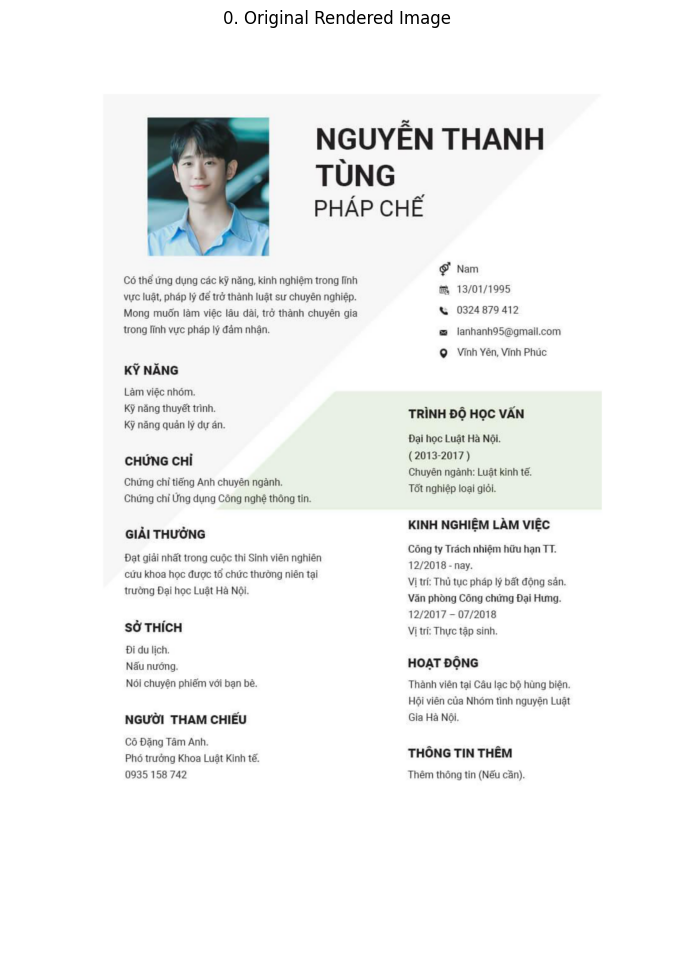

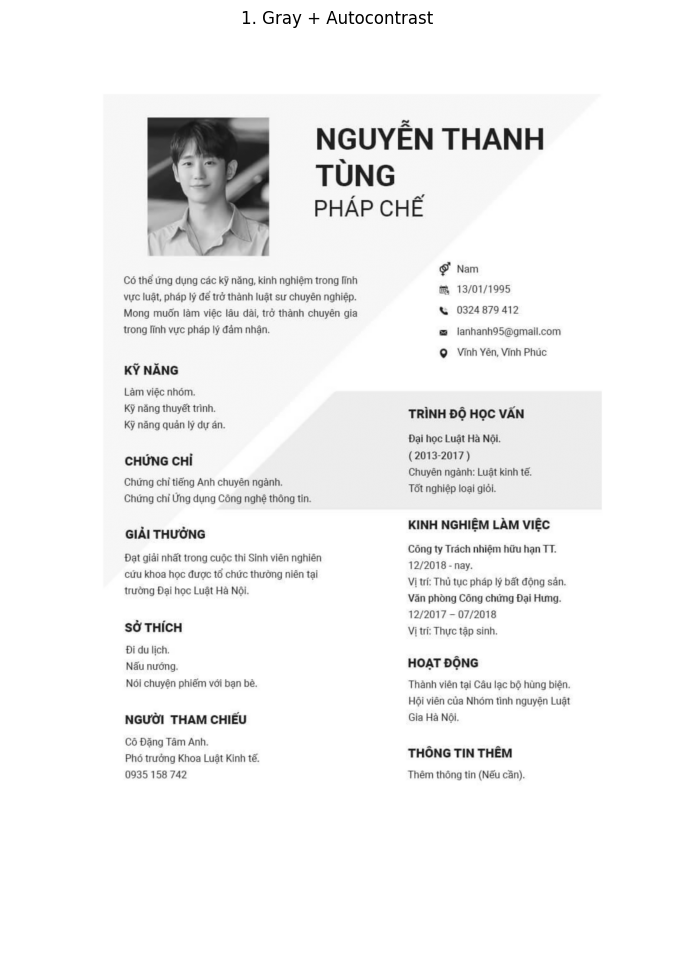

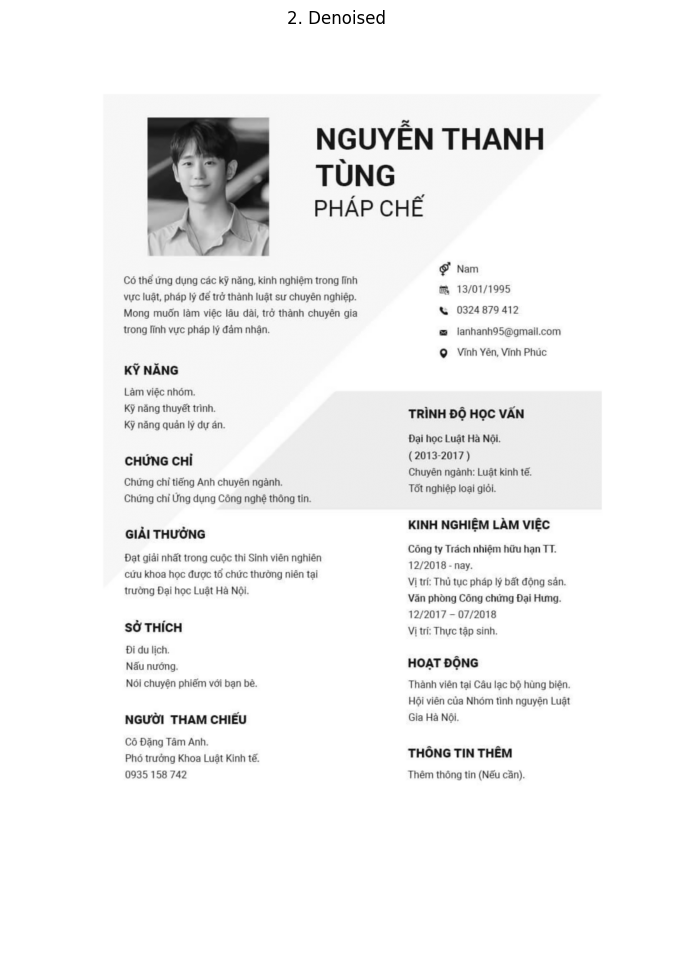

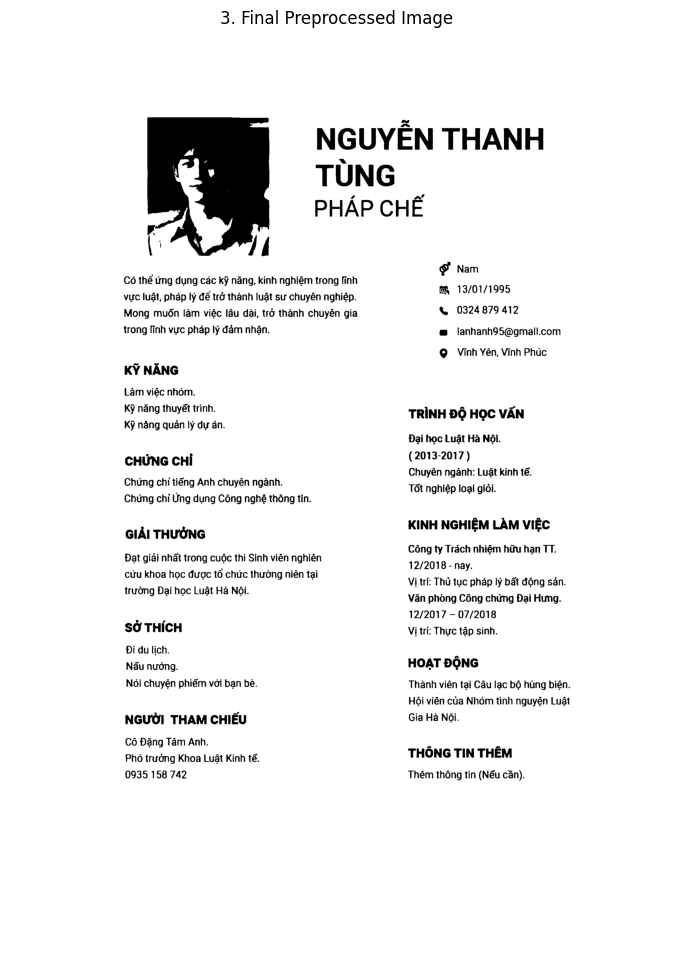

PDF type: scan_or_image_based
Method: ocr_words_layout_psm_3
Warnings: ['Đã dùng OCR word-level vì PDF có vẻ là file scan/ảnh.']
Da luu toan bo text vao file:
C:\Users\Admin\Downloads\CV_NTTung_extracted.txt


In [34]:
pdf_path = r"C://Users//Admin//Downloads//CV_NTTung.pdf"

extraction_result = extract_text_from_pdf(pdf_path)

print("PDF type:", extraction_result["pdf_type"])
print("Method:", extraction_result["method"])
print("Warnings:", extraction_result["warnings"])
    
# Save all extracted text to a txt file
output_path = Path(r"C://Users//Admin//Downloads//CV_NTTung_extracted.txt")

with open(output_path, "w", encoding="utf-8") as f:
    f.write("PDF type: " + str(extraction_result["pdf_type"]) + "\n")
    f.write("Method: " + str(extraction_result["method"]) + "\n")
    f.write("Warnings: " + str(extraction_result["warnings"]) + "\n")
    f.write("-" * 80 + "\n\n")
    f.write(extraction_result["text"])

print("Da luu toan bo text vao file:")
print(output_path)


## Stage 2 - Post-extraction cleaning


### 1. Clean each section


In [ ]:
# Sau khi trích xuất, có thể tiếp tục xử lý text để làm sạch và phân đoạn thành các phần như thông tin cá nhân, kỹ năng, kinh nghiệm, v.v.
import re
import unicodedata


def clean_post_line(text: str) -> str:
    # Nếu text rỗng hoặc None thì trả về chuỗi rỗng
    if not text:
        return ""

    # Ép về string để tránh lỗi nếu đầu vào không phải str
    text = str(text)

    # Chuẩn hóa unicode, giúp tiếng Việt và ký tự đặc biệt ổn định hơn
    text = unicodedata.normalize("NFC", text)

    # Thay các ký tự trắng đặc biệt thường gặp trong PDF thành khoảng trắng thường
    text = text.replace("\x00", " ")
    text = text.replace("\u00a0", " ")
    text = text.replace("\u200b", " ")  # zero-width space
    text = text.replace("\ufeff", " ")  # BOM

    # Xóa các ký tự Private Use Area
    # Nhiều icon trong CV/PDF được nhúng vào vùng này
    text = re.sub(r"[\ue000-\uf8ff]", " ", text)

    # Chuẩn hóa các dấu gạch ngang khác nhau về "-"
    text = re.sub(r"[–—−]", "-", text)

    # Chuẩn hóa bullet point thành "-"
    text = re.sub(r"[•●▪■◆▶►]", "-", text)

    # Xóa emoji/icon thật
    # Ví dụ: 📧 ☎ 📞 📍 🔗 🌐 🏠 🎂 👤
    text = re.sub(
        r"[\U0001F300-\U0001FAFF\u2600-\u27BF]",
        " ",
        text
    )

    # Xóa một số chuỗi lỗi mã hóa hay gặp khi đọc PDF
    # Ví dụ: â€¢, â€“, â€”, ðŸ...
    text = re.sub(r"ðŸ\S*", " ", text)
    text = text.replace("â€¢", "-")
    text = text.replace("â—", "-")
    text = text.replace("â–ª", "-")
    text = text.replace("â– ", "-")
    text = text.replace("â—†", "-")
    text = text.replace("â–¶", "-")
    text = text.replace("â–º", "-")
    text = text.replace("â€“", "-")
    text = text.replace("â€”", "-")

    # Xóa các ký tự điều khiển không cần thiết
    text = re.sub(r"[\x01-\x08\x0b\x0c\x0e-\x1f\x7f]", " ", text)

    # Gộp nhiều khoảng trắng/tab thành 1 khoảng trắng
    text = re.sub(r"[ \t]+", " ", text)

    text = re.sub(r"\s+([,:;])", r"\1", text)

    # Xóa khoảng trắng đầu/cuối dòng
    return text.strip()

def is_noise_line(text: str) -> bool:
    if not text:
        return True

    norm = normalize_for_heading(text)

    if not norm:
        return True

    if len(norm) <= 1:
        return True

    if re.fullmatch(r"[-_ ]+", text):
        return True

    return False

# Làm sạch các dòng trong một phần, loại bỏ dòng nhiễu và trùng lặp
def clean_section_lines(lines: list[str]) -> list[str]: 
    cleaned = []

    for line in lines:
        line = clean_post_line(line)

        if is_noise_line(line):
            continue

        cleaned.append(line)

    cleaned = dedupe_lines_keep_order(cleaned)
    return cleaned



### 2. Clean the full extraction result


In [ ]:
def clean_extraction_result(extraction_result: dict[str, Any]) -> dict[str, Any]:
    cleaned_result = {
        "text": "",
        "sections": {},
        "pdf_type": extraction_result.get("pdf_type", ""),
        "method": extraction_result.get("method", ""),
        "warnings": list(extraction_result.get("warnings", [])),
        "layout_debug": extraction_result.get("layout_debug", []),
    }

    raw_sections = extraction_result.get("sections", {})
    if not raw_sections:
        raw_sections = {section: [] for section in PREFERRED_SECTION_ORDER}

    cleaned_sections = {}

    for section in PREFERRED_SECTION_ORDER:
        lines = raw_sections.get(section, [])
        cleaned_sections[section] = clean_section_lines(lines)

    cleaned_result["sections"] = cleaned_sections
    cleaned_result["text"] = build_plain_text(cleaned_sections)

    if len(cleaned_result["text"]) < 300:
        cleaned_result["warnings"].append(
            "Cleaned text is still short. Check extraction quality before moving to field extraction."
        )

    return cleaned_result


In [ ]:
pdf_path = r"C:\Users\Admin\Downloads\CV_NTTung.pdf"

extraction_result = extract_text_from_pdf(pdf_path)
cleaned_result = clean_extraction_result(extraction_result)

print("PDF type:", cleaned_result["pdf_type"])
print("Method:", cleaned_result["method"])
print("Warnings:", cleaned_result["warnings"])
print("-" * 80)
print(cleaned_result["text"][:5000])

output_path = Path(r"C:\Users\Admin\Downloads\CV_NTTung_cleaned.txt")

with open(output_path, "w", encoding="utf-8") as f:
    f.write("PDF type: " + str(cleaned_result["pdf_type"]) + "\n")
    f.write("Method: " + str(cleaned_result["method"]) + "\n")
    f.write("Warnings: " + str(cleaned_result["warnings"]) + "\n")
    f.write("-" * 80 + "\n\n")
    f.write(cleaned_result["text"])

print("Da luu cleaned text vao file:")
print(output_path)



## Stage 3 - Field extraction


In [ ]:
import json
import spacy
from spacy.matcher import PhraseMatcher
from pathlib import Path
from typing import Any

nlp = spacy.load("en_core_web_sm")

DATA_DIR = Path(r"E:\Semester6\Laptrinhpython\project\data")

with open(DATA_DIR / "title_dict.json", "r", encoding="utf-8") as f:
    title_dict = json.load(f)

with open(DATA_DIR / "skill_dict.json", "r", encoding="utf-8") as f:
    skill_dict = json.load(f)

print("title_dict:", len(title_dict))
print("skill_dict:", len(skill_dict))
print(title_dict[:10])
print(skill_dict[:20])


In [ ]:
def normalize_term(term: str) -> str:
    term = clean_line_text(str(term)).strip().lower()
    term = re.sub(r"\s+", " ", term)
    return term

title_dict = sorted({normalize_term(t) for t in title_dict if normalize_term(t)})
skill_dict = sorted({normalize_term(s) for s in skill_dict if normalize_term(s)})

title_matcher = PhraseMatcher(nlp.vocab, attr="LOWER")
skill_matcher = PhraseMatcher(nlp.vocab, attr="LOWER")

title_matcher.add("JOB_TITLE", [nlp.make_doc(term) for term in title_dict])
skill_matcher.add("SKILL", [nlp.make_doc(term) for term in skill_dict])

print("title patterns:", len(title_dict))
print("skill patterns:", len(skill_dict))


- unique_keep_order: Làm sạch và bỏ trùng
- prepare_section: Làm sạch các section sau khi trích xuất từ CV/PDF
- join_lines: Nối nhiều dòng text thành một đoạn text
- get_first_match_text: Lấy kết quả match đầu tiên từ spaCy Matcher
- get_all_match_texts: Lấy tất cả kết quả match từ spaCy Matcher

In [ ]:
#Loại bỏ các phần tử trùng lặp
def unique_keep_order(items: list[str]) -> list[str]:
    result = []
    seen = set()

    for item in items:
        value = normalize_term(item)
        if not value:
            continue
        if value in seen:
            continue
        seen.add(value)
        result.append(value)

    return result

# Chuẩn hóa và làm sạch các dòng trong mỗi phần, đồng thời loại bỏ các dòng trùng lặp trong phần đó. Trả về một dictionary mới với các phần đã được làm sạch và chuẩn hóa.
def prepare_sections(extraction_result: dict[str, Any]) -> dict[str, list[str]]:
    raw_sections = extraction_result.get("sections", {})
    prepared = {}

    for section in PREFERRED_SECTION_ORDER:
        lines = raw_sections.get(section, [])
        cleaned = []

        for line in lines:
            line = clean_line_text(str(line))
            if not line:
                continue
            cleaned.append(line)

        prepared[section] = unique_keep_order(cleaned)

    return prepared


def join_lines(lines: list[str]) -> str:
    return "\n".join(lines).strip()

# doc: là văn bản đã được chuẩn hóa và làm sạch
# matcher: là một đối tượng PhraseMatcher đã được thiết lập với các mẫu cụ thể
# ví dụ: danh sách kỹ năng hoặc chức danh công việc
# Hàm này sẽ tìm kiếm tất cả các mẫu khớp trong văn bản
# và trả về văn bản của lần khớp đầu tiên, sau khi đã được chuẩn hóa.

# doc = nlp(text)
# => doc là tất cả các token đã phân tích từ text

# matcher chứa bộ luật/từ điển đã được tạo
# Nó sẽ quét qua doc xem từ/cụm từ nào khớp
# và trả về dạng (match_id, start, end)
def get_first_match_text(doc, matcher) -> str:
    matches = matcher(doc) 
    if not matches:
        return ""

    matches = sorted(matches, key=lambda x: (x[1], -(x[2] - x[1])))
    _, start, end = matches[0]
    return normalize_term(doc[start:end].text)


def get_all_match_texts(doc, matcher) -> list[str]:
    matches = matcher(doc)
    results = []

    for _, start, end in matches:
        results.append(normalize_term(doc[start:end].text))

    return unique_keep_order(results)


In [ ]:
# Hàm này sẽ trích xuất thông tin cá nhân như tên, email, số điện thoại từ phần header và personal_info
def extract_personal_info(extraction_result: dict[str, Any], sections: dict[str, list[str]]) -> dict[str, str]:
    full_text = extraction_result.get("text", "")
    header_lines = sections.get("header", []) + sections.get("personal_info", [])

    email_match = re.search(r"\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b", full_text)
    phone_match = re.search(r"(\+?\d[\d\-\s().]{8,}\d)", full_text)

    email = email_match.group(0).strip() if email_match else ""
    phone = phone_match.group(1).strip() if phone_match else ""

    name = ""
    for line in header_lines[:6]:
        if "@" in line:
            continue
        if re.search(r"\d", line):
            continue
        if len(line.split()) < 2 or len(line.split()) > 6:
            continue
        if detect_section_heading(line):
            continue
        name = line.strip()
        break

    return {
        "name": name,
        "email": email,
        "phone": phone
    }

# Hàm này sẽ trích xuất phần tóm tắt hoặc mục tiêu nghề nghiệp từ phần objective
def extract_summary(sections: dict[str, list[str]]) -> str:
    objective_lines = sections.get("objective", [])
    if objective_lines:
        return " ".join(objective_lines).strip()
    return ""


In [ ]:
def clean_skill_output(text: str) -> str:
    text = clean_line_text(str(text)).strip().lower()
    text = re.sub(r"\s+", " ", text)
    return text


def extract_skills(extraction_result: dict[str, Any], sections: dict[str, list[str]]) -> list[str]:
    def should_merge(prev_line: str, curr_line: str) -> bool:
        if not prev_line or not curr_line:
            return False

        prev_line = prev_line.strip()
        curr_line = curr_line.strip()

        if not curr_line:
            return False

        if curr_line[0].islower():
            return True

        if prev_line.count("(") > prev_line.count(")"):
            return True

        if prev_line.endswith((",", "-", "&", "/", ":")):
            return True

        return False

    raw_lines = sections.get("skills", [])
    merged_lines = []

    for raw_line in raw_lines:
        line = clean_skill_output(raw_line)
        if not line:
            continue

        line = re.sub(
            r"^(?:k? n?ng|ky nang|skills?)\s*[:\-]?\s*",
            "",
            line,
            flags=re.IGNORECASE,
        ).strip()

        if not line:
            continue

        if merged_lines and should_merge(merged_lines[-1], line):
            merged_lines[-1] = f"{merged_lines[-1]} {line}".strip()
        else:
            merged_lines.append(line)

    matched_skills = []

    for line in merged_lines:
        doc = nlp(line)
        matched_skills.extend(get_all_match_texts(doc, skill_matcher))

    if not matched_skills:
        full_text = extraction_result.get("text", "")
        doc = nlp(full_text)
        matched_skills.extend(get_all_match_texts(doc, skill_matcher))

    return unique_keep_order(matched_skills)


In [ ]:
def looks_like_title_line(line: str) -> bool:
    if not line:
        return False

    doc = nlp(line)
    has_title = bool(title_matcher(doc))

    if not has_title:
        return False

    if len(line.split()) > 12:
        return False

    return True


YEAR_RANGE_RE = re.compile(
    r"\b((?:19|20)\d{2})\s*[-\u2013\u2014]\s*((?:19|20)\d{2}|present|current|nay|hien tai)\b",
    flags=re.IGNORECASE
)


def strip_year_range(text: str) -> str:
    text = YEAR_RANGE_RE.sub("", text)
    text = re.sub(r"\s+", " ", text).strip(" -|,;")
    return text.strip()


def split_experience_blocks(lines: list[str]) -> list[list[str]]:
    blocks = []
    current_block = []

    for line in lines:
        line = line.strip()
        if not line:
            continue

        starts_new = False

        if current_block:
            if YEAR_RANGE_RE.search(normalize_for_heading(line)):
                starts_new = True
            elif looks_like_title_line(line):
                starts_new = True

        if starts_new:
            blocks.append(current_block)
            current_block = [line]
        else:
            current_block.append(line)

    if current_block:
        blocks.append(current_block)

    return blocks


def split_blocks_by_title(lines: list[str]) -> list[list[str]]:
    return split_experience_blocks(lines)


In [ ]:
def extract_experience(sections: dict[str, list[str]]) -> list[dict[str, str]]:
    lines = sections.get("experience", [])
    if not lines:
        return []

    blocks = split_experience_blocks(lines)
    results = []

    for block in blocks:
        if not block:
            continue

        header_line = block[0]
        doc = nlp(header_line)
        job_title = get_first_match_text(doc, title_matcher)

        if not job_title:
            job_title = normalize_term(strip_year_range(header_line))

        description_lines = block[1:] if len(block) > 1 else []
        description = " ".join(description_lines).strip()

        if job_title or description:
            results.append({
                "job_title": job_title,
                "description": description
            })

    return results


In [ ]:
DEGREE_PATTERNS = [
    (r"\b(ph\.?d|doctor(?:ate)?|tien si|ti?n s?)\b", "phd"),
    (r"\b(master|m\.?sc|mba|thac si|th?c s?)\b", "master"),
    (r"\b(bachelor|b\.?sc|b\.?eng|cu nhan|c? nh?n|dai hoc|??i h?c)\b", "bachelor"),
    (r"\b(college|cao dang|cao ??ng)\b", "college"),
    (r"\b(diploma|trung cap|trung c?p)\b", "diploma"),
]

SCHOOL_HINT_RE = re.compile(
    r"\b(truong|tr??ng|university|college|hoc vien|h?c vi?n|institute)\b",
    flags=re.IGNORECASE,
)

MAJOR_REGEX = re.compile(
    r"\b(?:in|major in|specialized in|specialization in)\s+([A-Za-z][A-Za-z\s&/\-]{2,60})",
    flags=re.IGNORECASE,
)


def extract_degree(text: str) -> str:
    norm = normalize_for_heading(text)

    for pattern, label in DEGREE_PATTERNS:
        if re.search(pattern, norm, flags=re.IGNORECASE):
            return label

    return ""


def looks_like_school_heading(line: str) -> bool:
    norm = normalize_for_heading(line)

    if not norm:
        return False

    if len(line.split()) > 18:
        return False

    return bool(
        re.match(
            r"^(truong|tr??ng|university|college|hoc vien|h?c vi?n|institute)\b",
            norm,
            flags=re.IGNORECASE,
        )
    )


def extract_major_from_block(block: list[str]) -> str:
    block_text = " ".join(block)

    match = MAJOR_REGEX.search(block_text)
    if match:
        major = match.group(1).strip()
        major = re.split(r"\b(?:19|20)\d{2}\b", major, maxsplit=1)[0]
        major = re.split(r"[,;|]", major, maxsplit=1)[0]
        return normalize_term(major)

    for line in block[1:4]:
        line_norm = normalize_for_heading(line)

        if not line_norm:
            continue
        if re.search(r"\b(truong|tr??ng|university|college|hoc vien|h?c vi?n|institute)\b", line_norm):
            continue
        if "gpa" in line_norm:
            continue
        if YEAR_RANGE_RE.search(line_norm):
            continue
        if line.endswith("."):
            continue
        if len(line.split()) > 14:
            continue

        return normalize_term(line)

    return ""


def split_education_blocks(lines: list[str]) -> list[list[str]]:
    blocks = []
    current_block = []

    for line in lines:
        line = line.strip()
        if not line:
            continue

        starts_new = False

        if current_block:
            if looks_like_school_heading(line):
                starts_new = True
            elif extract_degree(line):
                starts_new = True

        if starts_new:
            blocks.append(current_block)
            current_block = [line]
        else:
            current_block.append(line)

    if current_block:
        blocks.append(current_block)

    return blocks


def extract_education(sections: dict[str, list[str]]) -> list[dict[str, str]]:
    lines = sections.get("education", [])
    if not lines:
        return []

    blocks = split_education_blocks(lines)
    results = []

    for block in blocks:
        block_text = " ".join(block)
        degree = extract_degree(block_text)
        major = extract_major_from_block(block)

        if not degree and major:
            if len(major.split()) <= 2:
                continue
            if major.endswith("."):
                continue

        if degree or major:
            results.append({
                "degree": degree,
                "major": major,
            })

    return results


In [ ]:
def extract_projects(sections: dict[str, list[str]]) -> list[dict[str, str]]:
    lines = sections.get("projects", [])
    if not lines:
        return []

    blocks = split_blocks_by_title(lines)
    results = []

    for block in blocks:
        block_text = "\n".join(block)
        doc = nlp(block_text)

        role = get_first_match_text(doc, title_matcher)
        description = " ".join(block).strip()

        if role or description:
            results.append({
                "role": role,
                "description": description
            })

    return results


def parse_end_year(token: str) -> int | None:
    import datetime as _dt

    token = normalize_for_heading(token)

    if token in {"present", "current", "nay", "hien tai"}:
        return _dt.date.today().year

    if re.fullmatch(r"(?:19|20)\d{2}", token):
        return int(token)

    return None


def infer_total_years_from_experience(lines: list[str]) -> float | None:
    blocks = split_experience_blocks(lines)
    total_years = 0
    found = False

    for block in blocks:
        header_text = " ".join(block[:2])
        norm = normalize_for_heading(header_text)
        match = YEAR_RANGE_RE.search(norm)

        if not match:
            continue

        start_year = int(match.group(1))
        end_year = parse_end_year(match.group(2))

        if end_year is None:
            continue

        if end_year >= start_year:
            total_years += (end_year - start_year)
            found = True

    return float(total_years) if found else None


def extract_total_years_experience(extraction_result: dict[str, Any], sections: dict[str, list[str]]) -> float | None:
    search_text = normalize_for_heading(
        " ".join(sections.get("objective", [])) + "\n" + extraction_result.get("text", "")
    )

    patterns = [
        r"(\d+(?:\.\d+)?)\s+years?\s+of\s+experience",
        r"over\s+(\d+(?:\.\d+)?)\s+years?",
        r"more than\s+(\d+(?:\.\d+)?)\s+years?",
        r"(\d+(?:\.\d+)?)\s+nam\s+kinh\s+nghiem",
        r"tren\s+(\d+(?:\.\d+)?)\s+nam",
    ]

    for pattern in patterns:
        match = re.search(pattern, search_text, flags=re.IGNORECASE)
        if match:
            return float(match.group(1))

    return infer_total_years_from_experience(sections.get("experience", []))


In [ ]:
def build_candidate_profile_json(extraction_result: dict[str, Any]) -> dict[str, Any]:
    sections = prepare_sections(extraction_result)

    return {
        "candidate_profile": {
            "personal_info": extract_personal_info(extraction_result, sections),
            "summary": extract_summary(sections),
            "skills": extract_skills(extraction_result, sections),
            "experience": extract_experience(sections),
            "education": extract_education(sections),
            "project": extract_projects(sections),
            "total_years_experience": extract_total_years_experience(extraction_result, sections)
        }
    }


## Stage 4 - Final pipeline


In [ ]:
from pprint import pprint
import pandas as pd


def build_candidate_profile_text(candidate_json: dict[str, Any]) -> str:
    profile = candidate_json["candidate_profile"]
    chunks = []

    if profile.get("summary"):
        chunks.append(profile["summary"])

    skills = profile.get("skills", [])
    if skills:
        chunks.append(" ".join(skills))

    for item in profile.get("experience", []):
        if item.get("job_title"):
            chunks.append(item["job_title"])
        if item.get("description"):
            chunks.append(item["description"])

    for item in profile.get("education", []):
        if item.get("degree"):
            chunks.append(item["degree"])
        if item.get("major"):
            chunks.append(item["major"])

    for item in profile.get("project", []):
        if item.get("role"):
            chunks.append(item["role"])
        if item.get("description"):
            chunks.append(item["description"])

    return clean_cv_text("\n".join(chunks))


def process_cv_to_json(pdf_path: str | Path) -> dict[str, Any]:
    pdf_path = Path(pdf_path)

    extraction_result = extract_text_from_pdf(pdf_path)
    cleaned_result = clean_extraction_result(extraction_result)
    candidate_json = build_candidate_profile_json(cleaned_result)
    candidate_profile_text = build_candidate_profile_text(candidate_json)

    return {
        "pdf_path": str(pdf_path),
        "extraction_result": extraction_result,
        "cleaned_result": cleaned_result,
        "candidate_json": candidate_json,
        "candidate_profile_text": candidate_profile_text,
    }


def save_candidate_json(candidate_json: dict[str, Any], output_path: str | Path) -> Path:
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(candidate_json, f, ensure_ascii=False, indent=2)

    return output_path


In [ ]:
pdf_path = Path(r"C:\Users\Admin\Downloads\CV_PTTM.pdf")
processed_result = process_cv_to_json(pdf_path)
candidate_json = processed_result["candidate_json"]

pprint(candidate_json, sort_dicts=False)
print("\nCandidate profile text preview:")
print(processed_result["candidate_profile_text"][:1000])

output_json_path = Path(r"C:\Users\Admin\Downloads\CV_PTTM_candidate_profile.json")
save_candidate_json(candidate_json, output_json_path)

print("\nDa luu JSON vao:")
print(output_json_path)


## Stage 5 - Debug and validation


In [ ]:
def compact_text(text: str, max_len: int = 180) -> str:
    if not text:
        return ""
    text = str(text).strip().replace("\n", " ")
    text = re.sub(r"\s+", " ", text)
    if len(text) <= max_len:
        return text
    return text[:max_len] + "..."


def print_extraction_debug(
    extraction_result: dict,
    candidate_json: dict,
    preview_sections: bool = True,
    max_lines_per_section: int = 8,
) -> None:
    profile = candidate_json["candidate_profile"]

    print("=" * 100)
    print("PDF TYPE :", extraction_result.get("pdf_type"))
    print("METHOD   :", extraction_result.get("method"))
    print("WARNINGS :", extraction_result.get("warnings", []))
    print("=" * 100)

    print("\n[PERSONAL INFO]")
    pprint(profile.get("personal_info", {}), sort_dicts=False)

    print("\n[SUMMARY]")
    print(compact_text(profile.get("summary", ""), 300))

    print("\n[SKILLS]")
    print("count =", len(profile.get("skills", [])))
    print(profile.get("skills", []))

    print("\n[EXPERIENCE]")
    for i, item in enumerate(profile.get("experience", []), start=1):
        print(f"- experience[{i}]")
        print("  job_title   :", item.get("job_title", ""))
        print("  description :", compact_text(item.get("description", ""), 220))

    print("\n[EDUCATION]")
    for i, item in enumerate(profile.get("education", []), start=1):
        print(f"- education[{i}]")
        print("  degree :", item.get("degree", ""))
        print("  major  :", item.get("major", ""))

    print("\n[PROJECT]")
    for i, item in enumerate(profile.get("project", []), start=1):
        print(f"- project[{i}]")
        print("  role        :", item.get("role", ""))
        print("  description :", compact_text(item.get("description", ""), 220))

    print("\n[TOTAL YEARS EXPERIENCE]")
    print(profile.get("total_years_experience"))

    if preview_sections:
        print("\n" + "=" * 100)
        print("[SECTION PREVIEW]")
        print("=" * 100)

        sections = extraction_result.get("sections", {})
        for section in PREFERRED_SECTION_ORDER:
            lines = sections.get(section, [])
            if not lines:
                continue

            print(f"\n--- {section.upper()} ({len(lines)} lines) ---")
            for line in lines[:max_lines_per_section]:
                print(line)

            if len(lines) > max_lines_per_section:
                print("...")


In [ ]:
def flag_candidate_profile(extraction_result: dict, candidate_json: dict) -> list[str]:
    profile = candidate_json["candidate_profile"]
    flags = []

    personal_info = profile.get("personal_info", {})
    skills = profile.get("skills", [])
    experience = profile.get("experience", [])
    education = profile.get("education", [])
    projects = profile.get("project", [])
    total_years = profile.get("total_years_experience")

    if extraction_result.get("pdf_type") == "scan_or_image_based":
        flags.append("scan_pdf_requires_ocr")

    if len(extraction_result.get("text", "")) < 300:
        flags.append("short_extracted_text")

    if not personal_info.get("name"):
        flags.append("missing_name")
    if not personal_info.get("email"):
        flags.append("missing_email")
    if not personal_info.get("phone"):
        flags.append("missing_phone")
    if not skills:
        flags.append("missing_skills")
    if not experience:
        flags.append("missing_experience")
    if not education:
        flags.append("missing_education")

    empty_exp_titles = sum(1 for x in experience if not x.get("job_title"))
    if experience and empty_exp_titles >= max(1, len(experience) // 2):
        flags.append("many_empty_experience_titles")

    empty_project_roles = sum(1 for x in projects if not x.get("role"))
    if projects and empty_project_roles >= max(1, len(projects) // 2):
        flags.append("many_empty_project_roles")

    empty_education = sum(1 for x in education if not x.get("degree") and not x.get("major"))
    if education and empty_education > 0:
        flags.append("empty_education_items")

    if total_years is None:
        flags.append("missing_total_years_experience")

    return flags


In [ ]:
pdf_path = Path(r"C:\Users\Admin\Downloads\CV_PTTM.pdf")
processed_result = process_cv_to_json(pdf_path)
flags = flag_candidate_profile(processed_result["cleaned_result"], processed_result["candidate_json"])

print_extraction_debug(
    extraction_result=processed_result["cleaned_result"],
    candidate_json=processed_result["candidate_json"],
    preview_sections=True,
    max_lines_per_section=10,
)

print("\n[FLAGS]")
print(flags)


In [ ]:
def run_batch_extraction_debug(folder_path: str | Path, suffixes=(".pdf",)) -> list[dict]:
    folder_path = Path(folder_path)

    if not folder_path.exists():
        raise FileNotFoundError(f"Folder not found: {folder_path}")

    results = []

    for file_path in folder_path.rglob("*"):
        if not file_path.is_file():
            continue
        if file_path.suffix.lower() not in suffixes:
            continue

        try:
            processed_result = process_cv_to_json(file_path)
            flags = flag_candidate_profile(
                processed_result["cleaned_result"],
                processed_result["candidate_json"],
            )

            results.append({
                "file_path": str(file_path),
                "filename": file_path.name,
                "extraction_result": processed_result["extraction_result"],
                "cleaned_result": processed_result["cleaned_result"],
                "candidate_json": processed_result["candidate_json"],
                "candidate_profile_text": processed_result["candidate_profile_text"],
                "flags": flags,
                "error": "",
            })
        except Exception as e:
            results.append({
                "file_path": str(file_path),
                "filename": file_path.name,
                "extraction_result": {},
                "cleaned_result": {},
                "candidate_json": {},
                "candidate_profile_text": "",
                "flags": ["runtime_error"],
                "error": str(e),
            })

    return results


In [ ]:
def build_batch_summary_df(batch_results: list[dict]) -> pd.DataFrame:
    rows = []

    for item in batch_results:
        candidate_json = item.get("candidate_json", {})
        profile = candidate_json.get("candidate_profile", {}) if candidate_json else {}
        personal_info = profile.get("personal_info", {}) if profile else {}

        rows.append({
            "filename": item.get("filename", ""),
            "file_path": item.get("file_path", ""),
            "pdf_type": item.get("cleaned_result", {}).get("pdf_type", ""),
            "method": item.get("cleaned_result", {}).get("method", ""),
            "warning_count": len(item.get("cleaned_result", {}).get("warnings", [])),
            "flag_count": len(item.get("flags", [])),
            "flags": ", ".join(item.get("flags", [])),
            "has_name": bool(personal_info.get("name")),
            "has_email": bool(personal_info.get("email")),
            "has_phone": bool(personal_info.get("phone")),
            "skill_count": len(profile.get("skills", [])) if profile else 0,
            "experience_count": len(profile.get("experience", [])) if profile else 0,
            "education_count": len(profile.get("education", [])) if profile else 0,
            "project_count": len(profile.get("project", [])) if profile else 0,
            "total_years_experience": profile.get("total_years_experience") if profile else None,
            "profile_text_length": len(item.get("candidate_profile_text", "")),
            "error": item.get("error", ""),
        })

    df = pd.DataFrame(rows)

    if not df.empty:
        df = df.sort_values(
            by=["flag_count", "warning_count", "filename"],
            ascending=[False, False, True],
        ).reset_index(drop=True)

    return df


In [ ]:
cv_folder = Path(r"E:\Semester6\Laptrinhpython\project\media\cvs")
batch_results = run_batch_extraction_debug(cv_folder, suffixes=(".pdf",))
summary_df = build_batch_summary_df(batch_results)

print("So CV da xu ly:", len(batch_results))
display(summary_df.head(20))

debug_output_dir = Path(r"E:\Semester6\Laptrinhpython\project\data")
debug_output_dir.mkdir(parents=True, exist_ok=True)

summary_csv_path = debug_output_dir / "cv_extraction_summary.csv"
detail_json_path = debug_output_dir / "cv_extraction_debug.json"

summary_df.to_csv(summary_csv_path, index=False, encoding="utf-8")

json_ready = []
for item in batch_results:
    json_ready.append({
        "file_path": item["file_path"],
        "filename": item["filename"],
        "flags": item["flags"],
        "error": item["error"],
        "cleaned_result": item["cleaned_result"],
        "candidate_json": item["candidate_json"],
        "candidate_profile_text": item["candidate_profile_text"],
    })

with open(detail_json_path, "w", encoding="utf-8") as f:
    json.dump(json_ready, f, ensure_ascii=False, indent=2)

print("\nDa luu:")
print(summary_csv_path)
print(detail_json_path)


In [ ]:
def inspect_batch_item(batch_results: list[dict], filename_keyword: str) -> None:
    matched = [
        item for item in batch_results
        if filename_keyword.lower() in item.get("filename", "").lower()
    ]

    if not matched:
        print("Khong tim thay file phu hop.")
        return

    item = matched[0]

    print("FILE:", item["filename"])
    print("FLAGS:", item["flags"])
    print("ERROR:", item["error"])

    if item["error"]:
        return

    print_extraction_debug(
        extraction_result=item["cleaned_result"],
        candidate_json=item["candidate_json"],
        preview_sections=True,
        max_lines_per_section=12,
    )


In [ ]:
inspect_batch_item(batch_results, "CV_PTTM")


## Stage 6 - Batch export and matching prep


In [ ]:
def export_candidate_json_folder(
    folder_path: str | Path,
    output_dir: str | Path,
    suffixes=(".pdf",),
    include_profile_text: bool = True,
) -> pd.DataFrame:
    folder_path = Path(folder_path)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    rows = []

    for file_path in folder_path.rglob("*"):
        if not file_path.is_file():
            continue
        if file_path.suffix.lower() not in suffixes:
            continue

        processed_result = process_cv_to_json(file_path)
        candidate_json = processed_result["candidate_json"]
        candidate_profile_text = processed_result["candidate_profile_text"]

        json_path = output_dir / f"{file_path.stem}.json"
        save_candidate_json(candidate_json, json_path)

        profile_text_path = None
        if include_profile_text:
            profile_text_path = output_dir / f"{file_path.stem}_profile_text.txt"
            profile_text_path.write_text(candidate_profile_text, encoding="utf-8")

        rows.append({
            "filename": file_path.name,
            "json_path": str(json_path),
            "profile_text_path": str(profile_text_path) if profile_text_path else "",
            "skill_count": len(candidate_json["candidate_profile"].get("skills", [])),
            "experience_count": len(candidate_json["candidate_profile"].get("experience", [])),
            "education_count": len(candidate_json["candidate_profile"].get("education", [])),
            "profile_text_length": len(candidate_profile_text),
        })

    manifest_df = pd.DataFrame(rows)
    manifest_path = output_dir / "candidate_export_manifest.csv"
    manifest_df.to_csv(manifest_path, index=False, encoding="utf-8")

    print("Da luu manifest vao:")
    print(manifest_path)

    return manifest_df


In [ ]:
export_output_dir = Path(r"E:\Semester6\Laptrinhpython\project\data\candidate_json_exports")
manifest_df = export_candidate_json_folder(
    folder_path=cv_folder,
    output_dir=export_output_dir,
    suffixes=(".pdf",),
    include_profile_text=True,
)

display(manifest_df.head(20))
